# Server Telemetry Anomaly Detection (NAB Dataset)

This notebook detects anomalies in real server/system telemetry using the [NAB (Numenta Anomaly Benchmark)](https://github.com/numenta/NAB) dataset — real AWS CloudWatch metrics and industrial sensor data with human-confirmed ground-truth anomaly windows.

**Goal:** demonstrate a rigorous, evidence-driven progression of anomaly-detection methods (simple → complex), each evaluated honestly on precision/recall against real labels across all 7 files — rather than jumping straight to one final model and hoping it works.

**Methods evaluated, in order:**
1. Raw value comparison (sanity check — no method)
2. Rolling mean (magnitude-based threshold)
3. Rolling standard deviation (erratic-behavior-based threshold)
4. Combined rule (rolling mean OR rolling std)
5. Isolation Forest (unsupervised model on `[roll_mean, roll_std]`)

Each method is evaluated with `precision_score`/`recall_score` against NAB's real ground-truth anomaly windows, on every one of the 7 files below — never a single cherry-picked example. See the Step C error-analysis section near the end for the full per-file breakdown and the honest overall verdict on whether the model actually beat the hand-tuned rules.

**Files used (7 total):**
- 3 EC2 CPU utilization files (different servers)
- 1 EC2 network traffic file
- 1 RDS (database) CPU utilization file
- 1 industrial machine temperature file (real failure)
- 1 EC2 request latency file (real AWS outage)

## Setup — run this first
Loads libraries and defines the list of all 7 files + a helper function to load any file with its true anomaly labels attached.

In [1]:
import pandas as pd
import json
import urllib.request
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# All 7 files we're working with throughout this project.
# Keeping them in one list means every method gets tested on ALL of them,
# not just whichever file happened to look good — this avoids cherry-picking.
FILES = [
    'realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv',
    'realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv',
    'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv',
    'realAWSCloudwatch/ec2_network_in_5abac7.csv',
    'realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv',
    'realKnownCause/machine_temperature_system_failure.csv',
    'realKnownCause/ec2_request_latency_system_failure.csv',
]

# The NAB project provides real, human-confirmed anomaly time windows for each file.
# We load this ONCE here and reuse it for every file below.
LABELS_URL = 'https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_windows.json'
with urllib.request.urlopen(LABELS_URL) as response:
    ANOMALY_WINDOWS = json.load(response)


def load_file(key):
    '''
    Loads one NAB file directly from the web (no local download needed),
    and adds an 'is_anomaly' column (1 = inside a real labeled anomaly window, 0 = normal).

    key: the file path as it appears in the NAB repo, e.g.
         'realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv'
    '''
    url = 'https://raw.githubusercontent.com/numenta/NAB/master/data/' + key
    df = pd.read_csv(url)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    df['is_anomaly'] = 0
    for start, end in ANOMALY_WINDOWS.get(key, []):
        start, end = pd.to_datetime(start), pd.to_datetime(end)
        df.loc[(df['timestamp'] >= start) & (df['timestamp'] <= end), 'is_anomaly'] = 1

    return df

print("Setup complete. FILES list has", len(FILES), "entries.")


Setup complete. FILES list has 7 entries.


---
## Day 2 — Checking if the raw value alone can detect anomalies

**Method:** none yet — just comparing the average value during normal periods vs. anomalous periods, for every file. This is the simplest possible check, and we do it BEFORE trying anything fancier, to see if we even need to.

**Why we're doing this:** if raw values were already clearly different during anomalies, we wouldn't need rolling windows or models at all — always check the simplest thing first.


In [2]:
# For each file: compute the average (mean) and spread (std) of the raw
# sensor/metric value, separately for normal rows and anomalous rows.
# If a method is going to work, we'd expect these two groups to look
# clearly different from each other.

day2_results = []

for key in FILES:
    df = load_file(key)
    stats = df.groupby('is_anomaly')['value'].agg(['mean', 'std'])
    normal_mean, normal_std = stats.loc[0, 'mean'], stats.loc[0, 'std']
    if 1 in stats.index:
        anomaly_mean, anomaly_std = stats.loc[1, 'mean'], stats.loc[1, 'std']
    else:
        anomaly_mean, anomaly_std = float('nan'), float('nan')
    day2_results.append({
        'file': key,
        'normal_mean': normal_mean, 'normal_std': normal_std,
        'anomaly_mean': anomaly_mean, 'anomaly_std': anomaly_std,
    })

day2_df = pd.DataFrame(day2_results)
day2_df


,file,normal_mean,normal_std,anomaly_mean,anomaly_std
0,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,1.827182,0.098106,1.850985,1.259423e-01
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0.125478,0.088765,0.133756,1.378321e-01
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,43.045893,4.264975,43.692603,4.602371e+00
3,realAWSCloudwatch/ec2_network_in_5abac7.csv,96701.891001,691669.688217,316365.004641,1.291888e+06
4,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,18.927097,5.489507,19.005034,6.565549e+00
5,realKnownCause/machine_temperature_system_fail...,88.359144,9.786469,64.016597,2.225426e+01
6,realKnownCause/ec2_request_latency_system_fail...,45.156150,1.920229,45.152931,4.661792e+00


**Real results (captured for reference — your numbers should match closely):**

| file | normal_mean | normal_std | anomaly_mean | anomaly_std |
|---|---|---|---|---|
| ec2_cpu_utilization_53ea38 | 1.827 | 0.098 | 1.851 | 0.126 |
| ec2_cpu_utilization_24ae8d | 0.125 | 0.089 | 0.134 | 0.138 |
| ec2_cpu_utilization_5f5533 | 43.046 | 4.265 | 43.693 | 4.602 |
| ec2_network_in_5abac7 | 96,701.9 | 691,669.7 | 316,365.0 | 1,291,888.3 |
| rds_cpu_utilization_e47b3b | 18.927 | 5.490 | 19.005 | 6.566 |
| machine_temperature_system_failure | 88.359 | 9.786 | 64.017 | 22.254 |
| ec2_request_latency_system_failure | 45.156 | 1.920 | 45.153 | 4.662 |

**What this tells us, file by file:**
- Most CPU files (`53ea38`, `24ae8d`, `5f5533`) and the RDS file: normal and anomaly means are **almost identical** — raw value does NOT separate anomaly from normal here.
- `ec2_network_in_5abac7`: anomaly mean (316,365) is **~3.3x** the normal mean (96,702) — a real, visible difference. Raw value DOES help here.
- `machine_temperature_system_failure`: anomaly mean (64.0) is clearly LOWER than normal (88.4) — also a real difference, but in the opposite direction (a drop, not a spike).
- `ec2_request_latency_system_failure`: means are nearly identical, but anomaly **std** (4.662) is much higher than normal std (1.920) — hints that erratic behavior, not average level, might matter more here.

**Conclusion for Day 2:** raw value alone is a strong signal for only 2 of 7 files (network traffic, temperature), a weak-but-present hint for 1 file (latency, via std not mean), and essentially useless for the other 4. This tells us we need a smarter method — motivating Day 3.


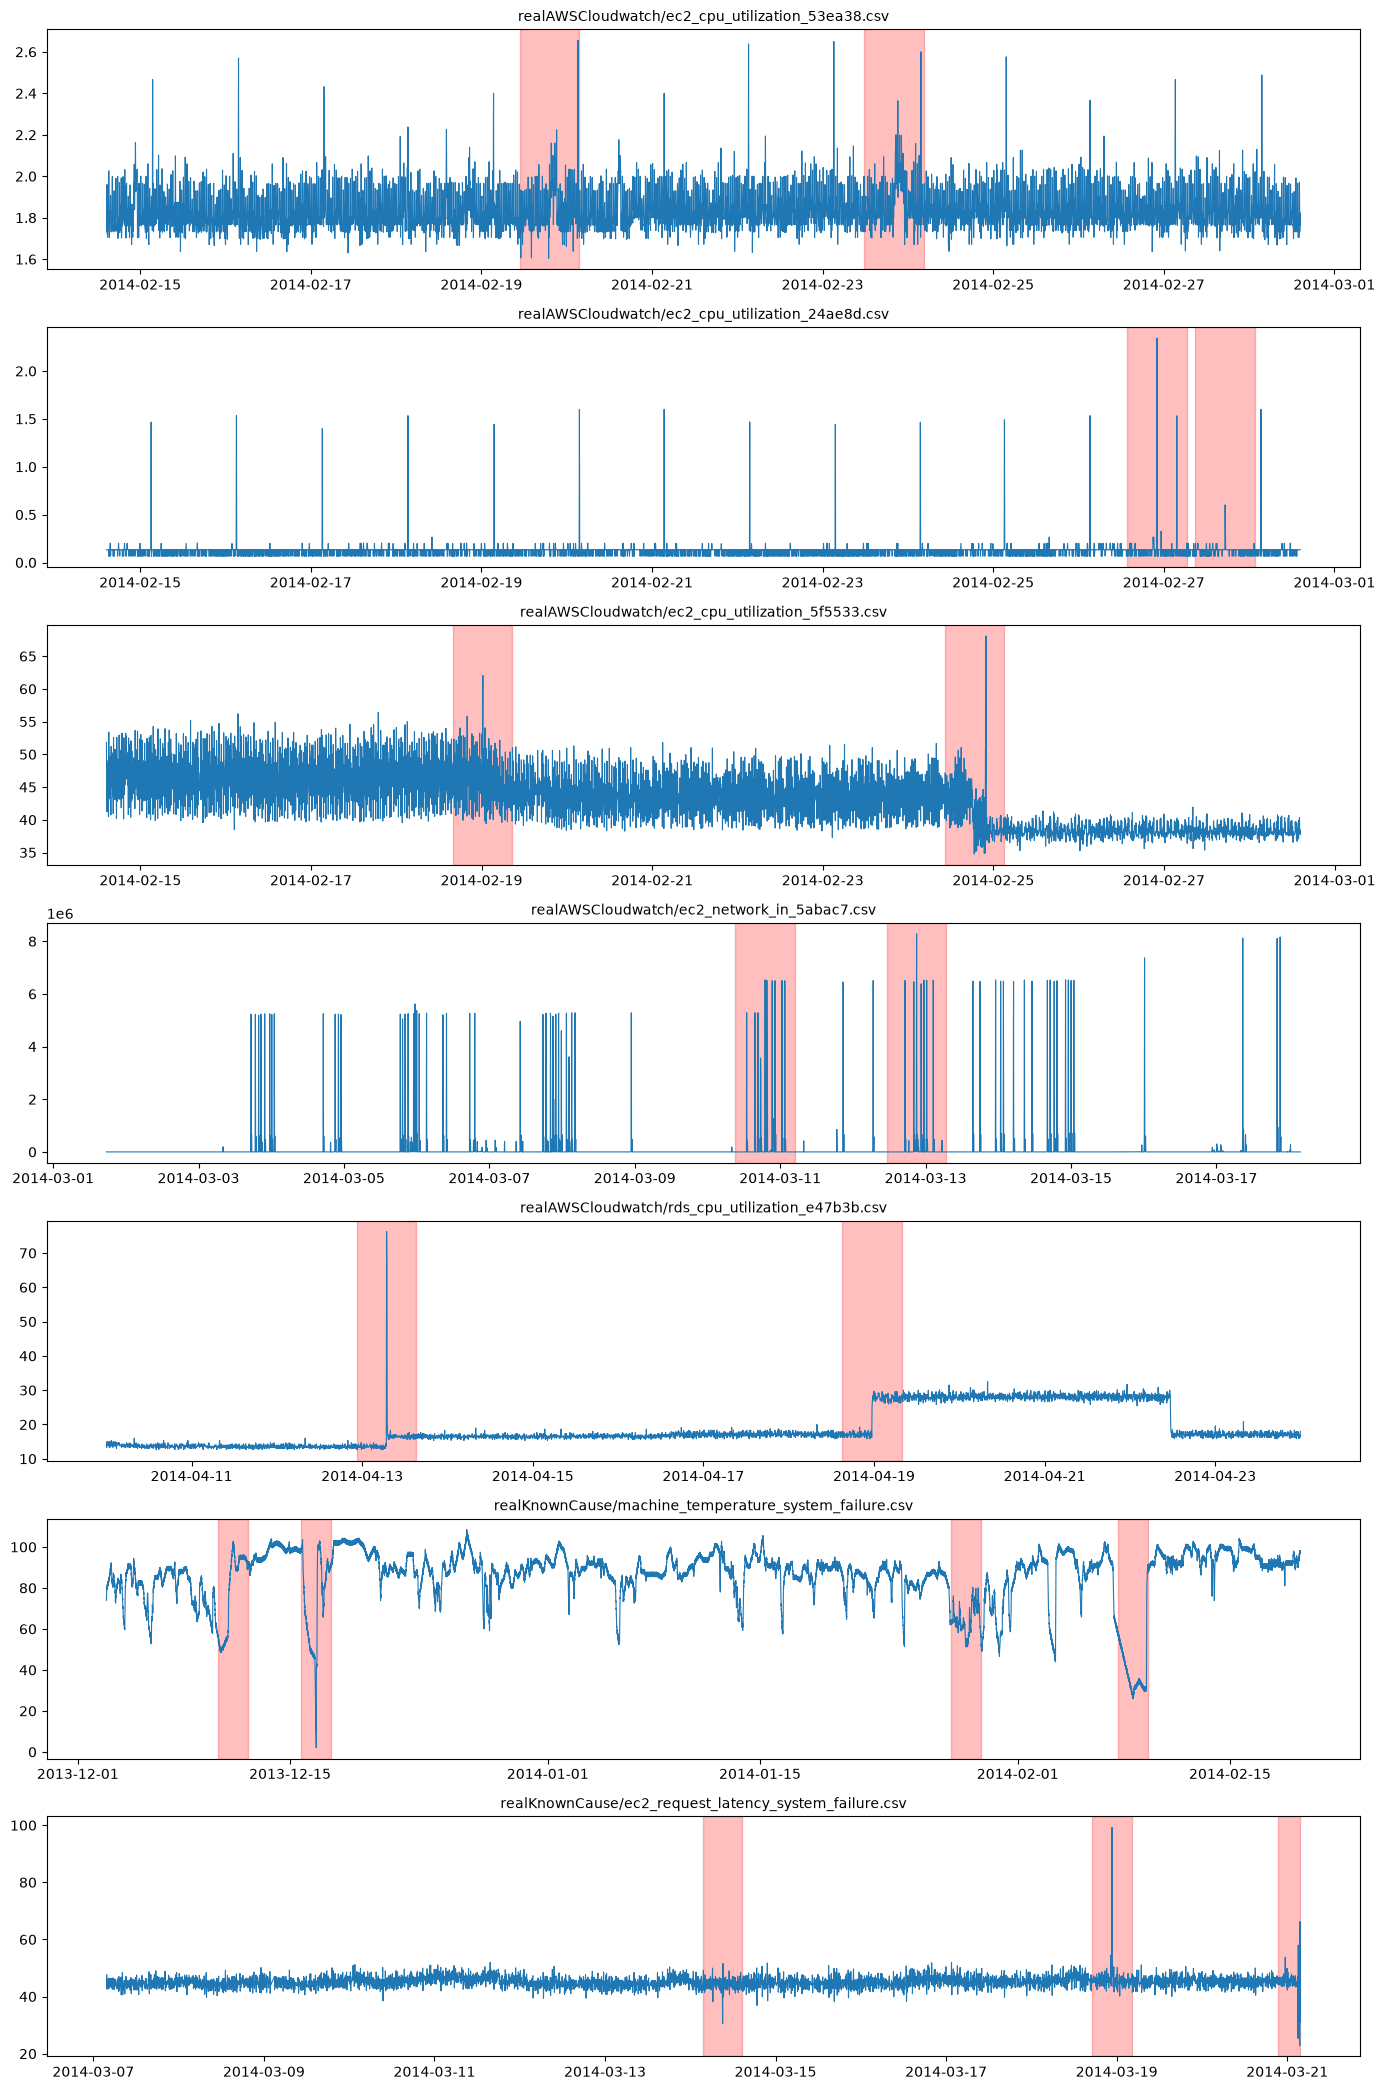

In [3]:
# Quick visual check: plot the raw values for ALL 7 files, with true anomaly
# windows shaded in red. This is the fastest way to SEE what Day 2's numbers
# only described. Look at each plot and ask: "does red overlap with unusual-looking value behavior?"

fig, axes = plt.subplots(len(FILES), 1, figsize=(14, 3 * len(FILES)))

for ax, key in zip(axes, FILES):
    df = load_file(key)
    ax.plot(df['timestamp'], df['value'], linewidth=0.8)
    for start, end in ANOMALY_WINDOWS.get(key, []):
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.25)
    ax.set_title(key, fontsize=10)

plt.tight_layout()
plt.show()


---
## Day 3 — Method: Rolling Mean

**What it is (plain terms):** instead of looking at one reading, look at the average of the last few readings (we use the last 6 = last 30 minutes, since data is recorded every 5 minutes). This smooths out random noise and reveals sustained shifts.

**Why we're trying it:** Day 2 showed raw value alone mostly doesn't work. Rolling mean is the simplest upgrade — average a small recent window instead of looking at one point in isolation.

**Method used for flagging:** if a row's rolling mean goes above `(overall mean + 1.0 x overall std)` for that file, flag it as a predicted anomaly. This threshold was chosen via a manual sweep on one file (see notes below) — it is a simple, deliberately basic first attempt, not a tuned final method.


In [4]:
# Rolling mean, computed and evaluated (precision/recall) for every file.
# WINDOW = 6 means "the last 6 readings" = last 30 minutes of data (5-min intervals).

WINDOW = 6
day3_results = []

for key in FILES:
    df = load_file(key)

    # Rolling mean: for each row, average of itself + the previous (WINDOW-1) readings.
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()

    # Threshold: a simple global cutoff based on this file's own overall mean/std.
    threshold = df['value'].mean() + 1.0 * df['value'].std()

    # Flag = 1 if the SMOOTHED (rolling mean) value crosses the threshold.
    df['flag'] = (df['roll_mean'] > threshold).astype(int)

    precision = precision_score(df['is_anomaly'], df['flag'], zero_division=0)
    recall = recall_score(df['is_anomaly'], df['flag'], zero_division=0)

    day3_results.append({'file': key, 'precision': precision, 'recall': recall})

day3_df = pd.DataFrame(day3_results)
day3_df


,file,precision,recall
0,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,0.417910,0.139303
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0.178947,0.042289
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,0.187500,0.052239
3,realAWSCloudwatch/ec2_network_in_5abac7.csv,0.251928,0.206751
4,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,0.101779,0.256219
5,realKnownCause/machine_temperature_system_fail...,0.047481,0.036155
6,realKnownCause/ec2_request_latency_system_fail...,0.200000,0.023121


**Real results (captured for reference):**

| file | precision | recall |
|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.42 | 0.14 |
| ec2_cpu_utilization_24ae8d | 0.18 | 0.04 |
| ec2_cpu_utilization_5f5533 | 0.19 | 0.05 |
| ec2_network_in_5abac7 | 0.25 | 0.21 |
| rds_cpu_utilization_e47b3b | 0.10 | 0.26 |
| machine_temperature_system_failure | 0.05 | 0.04 |
| ec2_request_latency_system_failure | 0.20 | 0.02 |

**Reminder — precision vs recall, plain terms:**
- Precision: of everything flagged, what fraction was a REAL anomaly? (low = lots of false alarms)
- Recall: of all REAL anomalies, what fraction did we catch? (low = we miss most real problems)

**What this tells us:** every file has at least one of the two numbers below 0.3 — this is a genuinely weak baseline everywhere. Rolling mean gives SOME signal above pure guessing (especially on `53ea38` and `network_in`), but is nowhere near reliable on its own, on any single file.

**Correction note (for accuracy — leave this comment in place):** an earlier informal test suggested `53ea38` performed "close to catching nothing" with rolling mean — that claim was made WITHOUT running this exact evaluation first, and turned out to be wrong. The verified number (precision 0.42, recall 0.14) is moderate-precision-but-low-recall, not "nothing." Lesson: always verify a claim with actual code/numbers before writing it down.


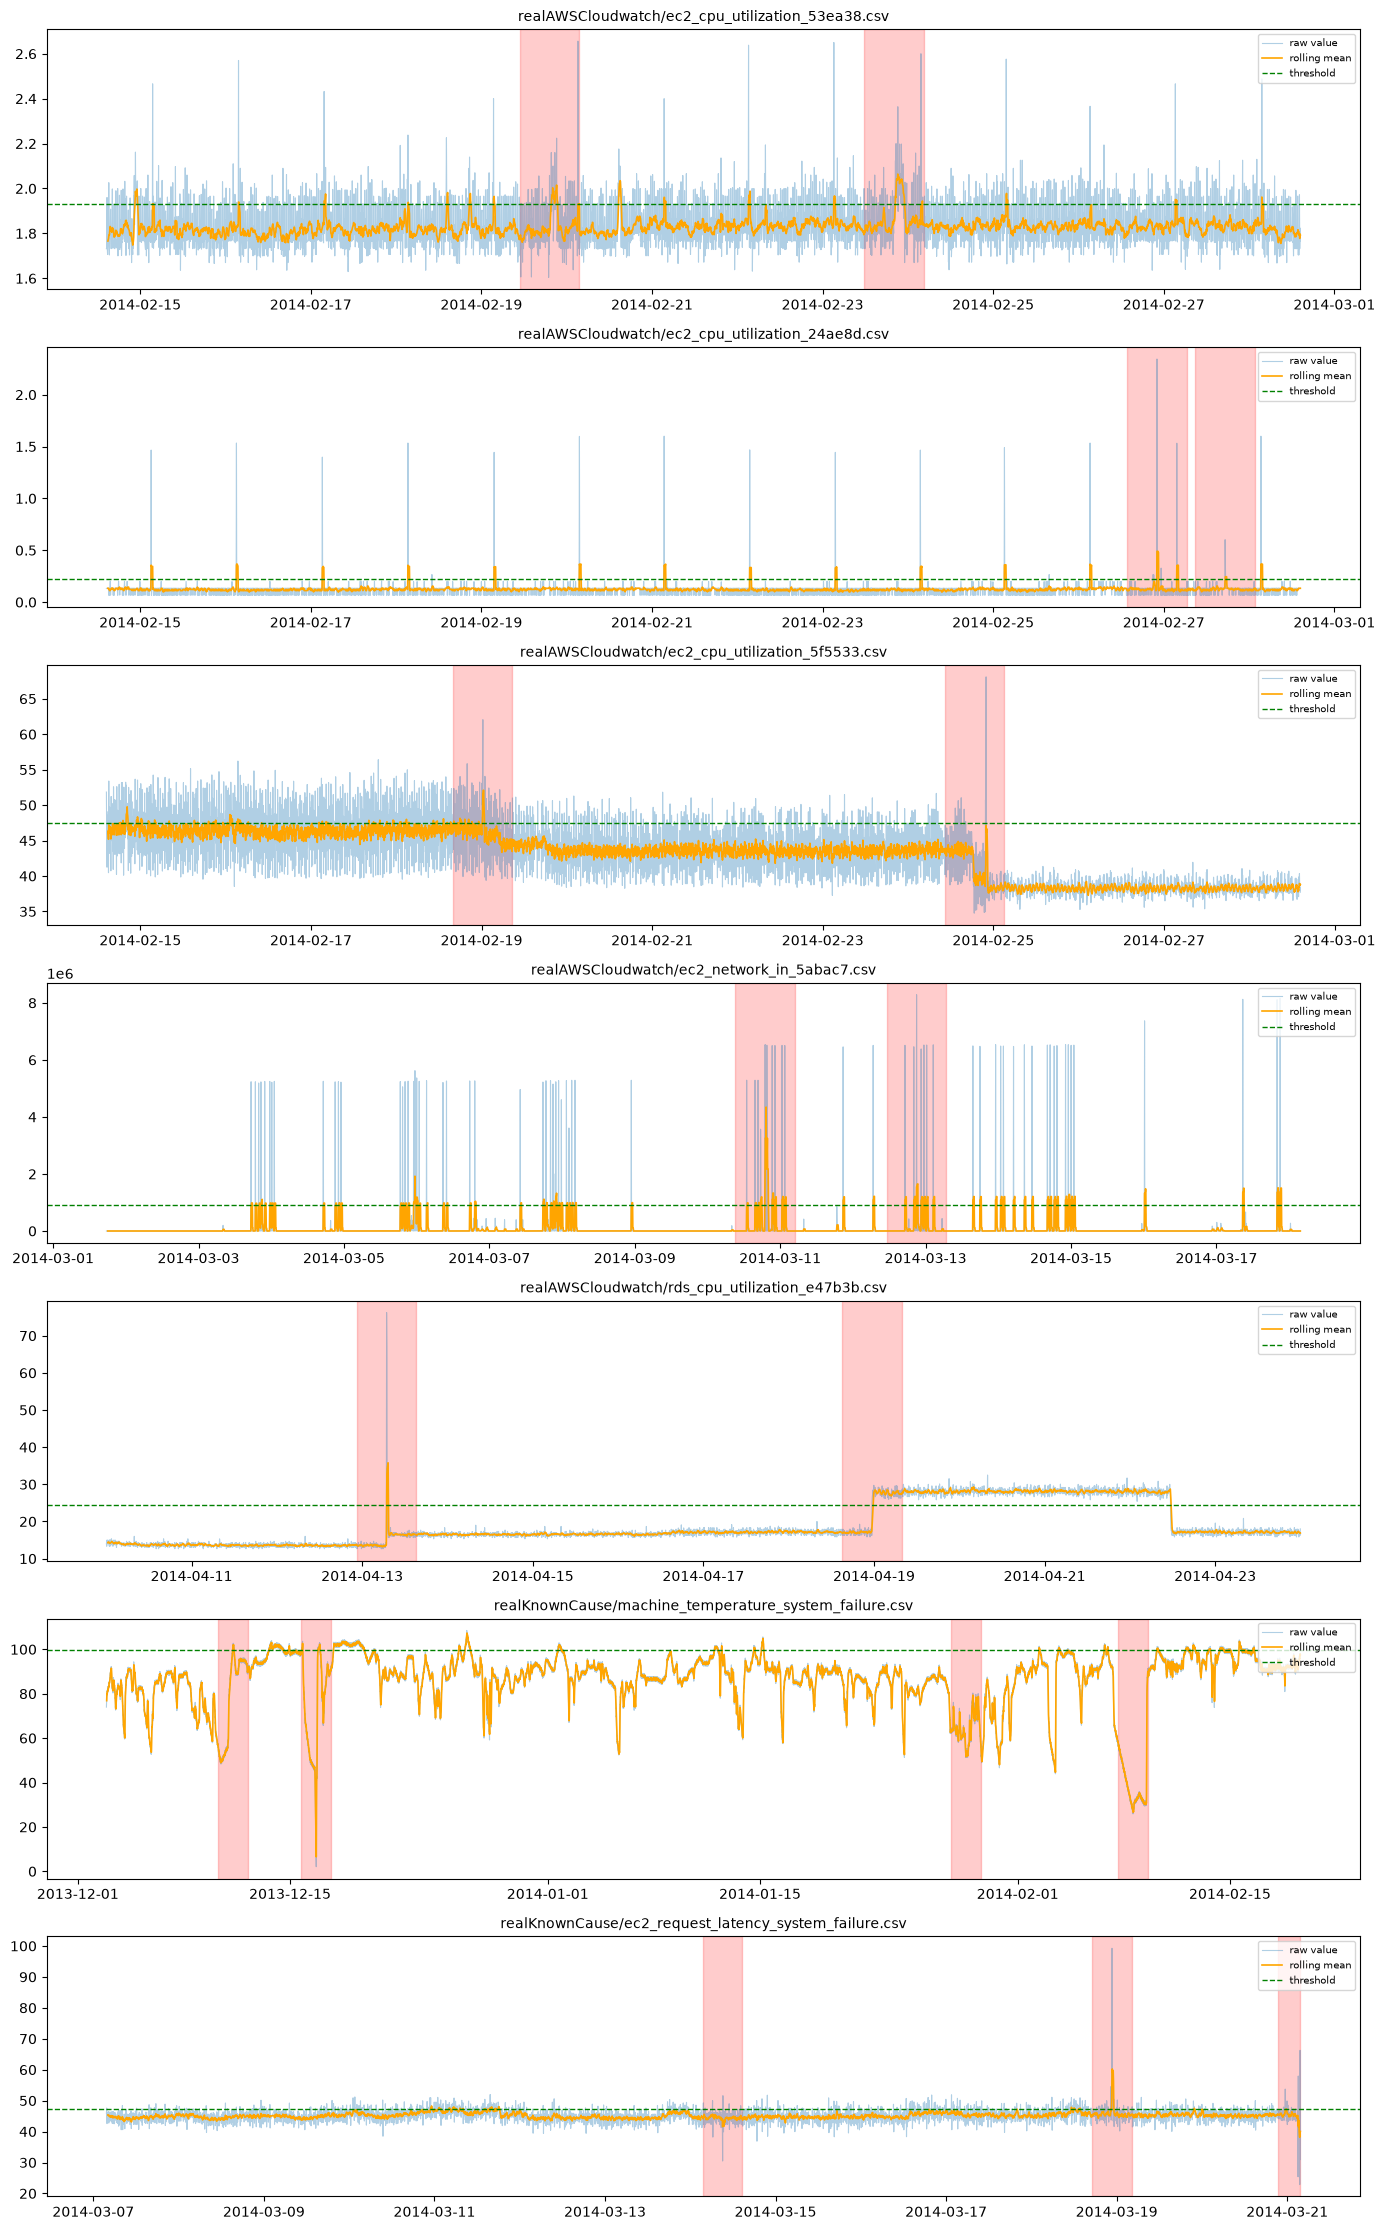

In [5]:
# Visual check: for each file, plot RAW value (faint) + ROLLING MEAN (bold orange)
# + true anomaly windows (red shading) + the threshold line (green dashed).
# This lets you SEE why precision/recall came out the way they did per file --
# e.g. does the orange line actually rise above the green line during red zones?

fig, axes = plt.subplots(len(FILES), 1, figsize=(14, 3.2 * len(FILES)))

for ax, key in zip(axes, FILES):
    df = load_file(key)
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()
    threshold = df['value'].mean() + 1.0 * df['value'].std()

    ax.plot(df['timestamp'], df['value'], alpha=0.35, linewidth=0.8, label='raw value')
    ax.plot(df['timestamp'], df['roll_mean'], color='orange', linewidth=1.2, label='rolling mean')
    ax.axhline(threshold, color='green', linestyle='--', linewidth=1, label='threshold')
    for start, end in ANOMALY_WINDOWS.get(key, []):
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.2)

    ax.set_title(key, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


### Day 3 summary (write this in your own words in the notebook too)

Rolling mean helps a little over raw values on some files, but is unreliable across most of the 7 files tested — no file shows both strong precision AND strong recall. This is real, table-backed evidence that a single feature (even a smoothed one) is not enough for a general-purpose anomaly detector across different servers/metrics. This motivates trying a second kind of feature next (rolling standard deviation), and eventually combining multiple features into a real model instead of one hand-picked threshold.


---
## Day 4 — Method: Rolling Standard Deviation

**What it is (plain terms):** rolling standard deviation measures how ERRATIC or JUMPY the last few readings have been, rather than how big they are.

Example: two servers both averaging 50% CPU right now —
- Server A: last 6 readings = 48, 51, 49, 50, 52, 49 -> steady, low spread
- Server B: last 6 readings = 20, 80, 15, 90, 10, 85 -> wild swings, high spread

Both have the same rolling MEAN (~50), so rolling mean treats them almost identically.
Rolling STD is the number that tells them apart.

**Why we're trying this:** Day 3 showed rolling mean catches magnitude-based anomalies but
misses some anomalies that might be pattern/erratic-behavior-based instead. Rolling std is
a direct test of that idea: does measuring "how jumpy is it right now" catch anomalies that
measuring "how big is it right now" missed?


In [6]:
# Rolling standard deviation, computed and evaluated (precision/recall) for every file.
# Same WINDOW (6 readings = 30 minutes) as Day 3, so the comparison between
# rolling mean and rolling std is fair -- only the FEATURE changes, nothing else.

day4_results = []

for key in FILES:
    df = load_file(key)

    # Rolling std: for each row, the standard deviation of itself + the previous
    # (WINDOW-1) readings. High value = readings have been bouncing around a lot recently.
    df['roll_std'] = df['value'].rolling(WINDOW).std()

    # Threshold: based on the DISTRIBUTION OF ROLLING STD ITSELF for this file
    # (not the raw value's mean/std, since we're now thresholding a different quantity).
    threshold = df['roll_std'].mean() + 1.0 * df['roll_std'].std()

    df['flag'] = (df['roll_std'] > threshold).astype(int)

    precision = precision_score(df['is_anomaly'], df['flag'], zero_division=0)
    recall = recall_score(df['is_anomaly'], df['flag'], zero_division=0)

    day4_results.append({'file': key, 'precision': precision, 'recall': recall})

day4_df = pd.DataFrame(day4_results)
day4_df


,file,precision,recall
0,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,0.183230,0.146766
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0.187500,0.044776
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,0.133858,0.211443
3,realAWSCloudwatch/ec2_network_in_5abac7.csv,0.229614,0.225738
4,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,0.541667,0.032338
5,realKnownCause/machine_temperature_system_fail...,0.200000,0.102734
6,realKnownCause/ec2_request_latency_system_fail...,0.260606,0.124277


**Real results (captured for reference):**

| file | precision | recall |
|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.18 | 0.15 |
| ec2_cpu_utilization_24ae8d | 0.19 | 0.04 |
| ec2_cpu_utilization_5f5533 | 0.13 | 0.21 |
| ec2_network_in_5abac7 | 0.23 | 0.23 |
| rds_cpu_utilization_e47b3b | 0.54 | 0.03 |
| machine_temperature_system_failure | 0.20 | 0.10 |
| ec2_request_latency_system_failure | 0.26 | 0.12 |

### Side-by-side: rolling mean (Day 3) vs rolling std (Day 4)

| file | mean: P / R | std: P / R | which won? |
|---|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.42 / 0.14 | 0.18 / 0.15 | mean (higher precision) |
| ec2_cpu_utilization_24ae8d | 0.18 / 0.04 | 0.19 / 0.04 | roughly tied, both weak |
| ec2_cpu_utilization_5f5533 | 0.19 / 0.05 | 0.13 / 0.21 | std (much better recall) |
| ec2_network_in_5abac7 | 0.25 / 0.21 | 0.23 / 0.23 | roughly tied |
| rds_cpu_utilization_e47b3b | 0.10 / 0.26 | 0.54 / 0.03 | depends on goal (mean=more catches, std=fewer false alarms) |
| machine_temperature_system_failure | 0.05 / 0.04 | 0.20 / 0.10 | std, clearly better |
| ec2_request_latency_system_failure | 0.20 / 0.02 | 0.26 / 0.12 | std, better on both |

**What this tells us, in plain terms:**
- Rolling std WINS on 3 files (5f5533, temperature, latency) -- these are likely anomalies
  that show up as erratic/jumpy behavior rather than a simple size increase.
- Rolling mean WINS on 1 file (53ea38) -- this anomaly is more about a sustained level shift.
- 2 files are roughly a tie, and both methods are weak on rds_cpu (mean catches more, std is
  more trustworthy when it does flag, but neither is good).

**The single most important conclusion from Day 3 + Day 4 together:**
NO single feature (raw value, rolling mean, or rolling std) is reliably good across all 7
files. Every method's best score on any file is still well under what a production system
would need. This is real, table-backed evidence -- not a guess -- that the next step must be
COMBINING features together (so a model can use magnitude AND erraticness at once), rather
than continuing to test one feature at a time.


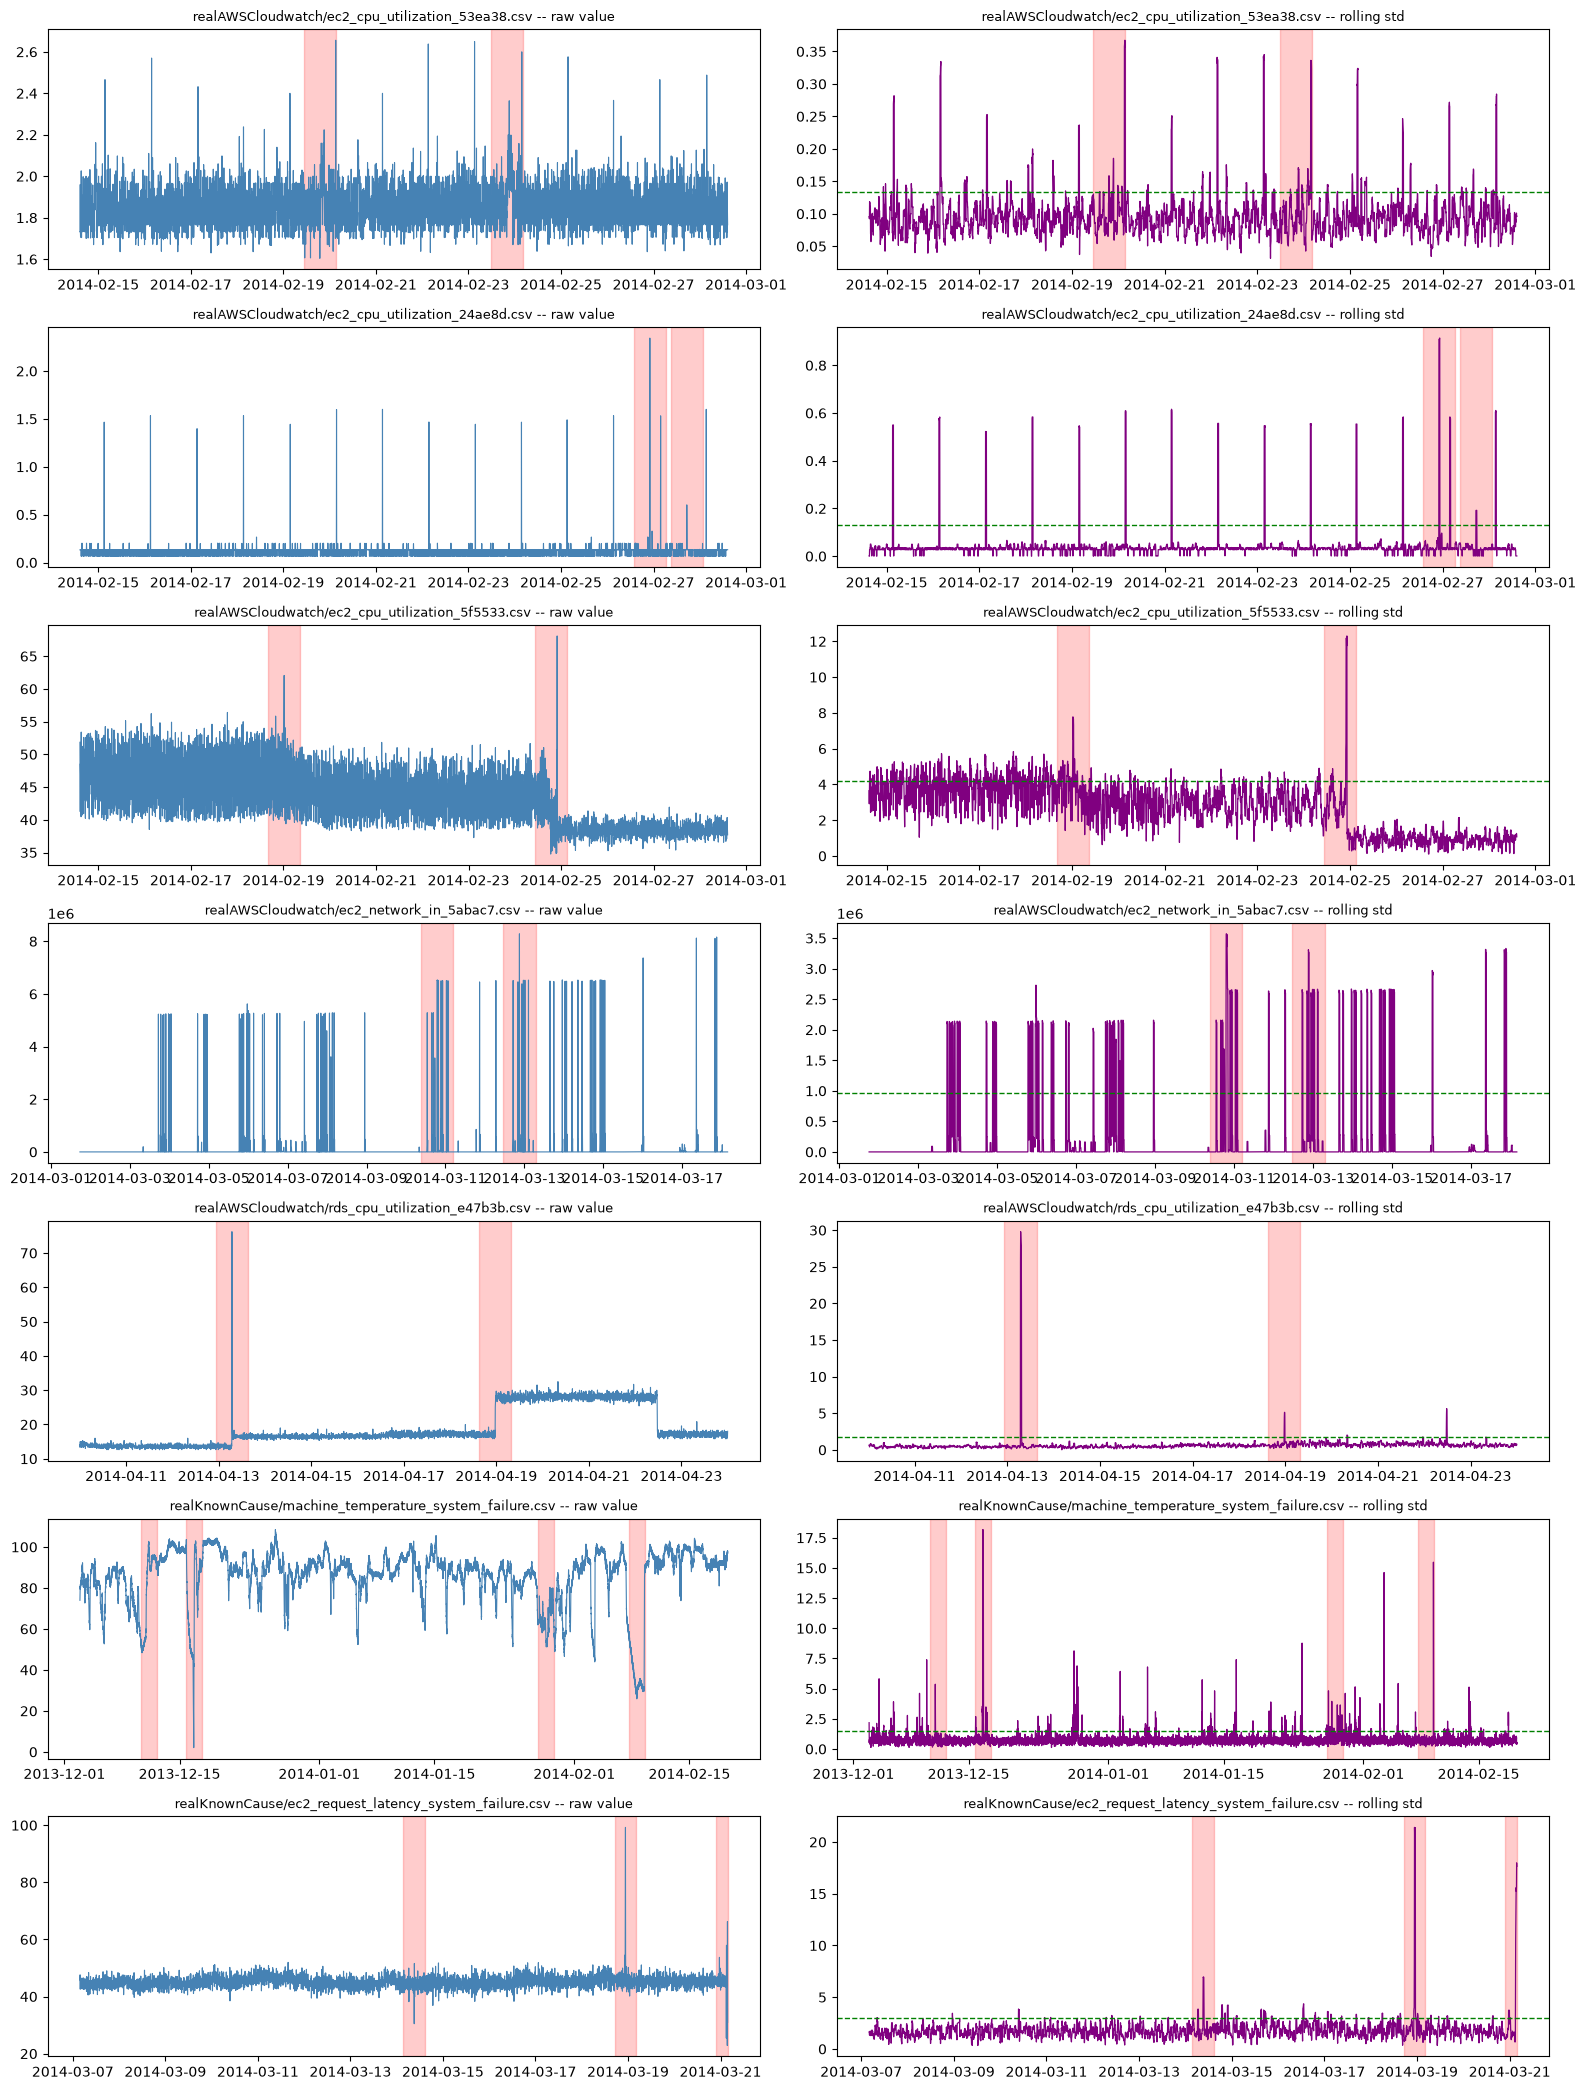

In [7]:
# Visual check: same style as Day 3's plot, but showing ROLLING STD instead of rolling mean.
# Plotted on a SEPARATE axis under each file's raw value, since rolling std is a very
# different scale/unit than the raw value itself.

fig, axes = plt.subplots(len(FILES), 2, figsize=(16, 3 * len(FILES)))

for row, key in zip(axes, FILES):
    df = load_file(key)
    df['roll_std'] = df['value'].rolling(WINDOW).std()
    threshold = df['roll_std'].mean() + 1.0 * df['roll_std'].std()

    ax_raw, ax_std = row

    # Left plot: raw value with true anomalies
    ax_raw.plot(df['timestamp'], df['value'], linewidth=0.8, color='steelblue')
    for start, end in ANOMALY_WINDOWS.get(key, []):
        ax_raw.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.2)
    ax_raw.set_title(key + ' -- raw value', fontsize=9)

    # Right plot: rolling std with threshold and true anomalies
    ax_std.plot(df['timestamp'], df['roll_std'], linewidth=0.9, color='purple')
    ax_std.axhline(threshold, color='green', linestyle='--', linewidth=1)
    for start, end in ANOMALY_WINDOWS.get(key, []):
        ax_std.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.2)
    ax_std.set_title(key + ' -- rolling std', fontsize=9)

plt.tight_layout()
plt.show()


### Day 4 summary (write this in your own words in the notebook too)

Rolling standard deviation catches a different subset of anomalies than rolling mean does --
neither is consistently better, and both are individually weak across most of the 7 files.
This confirms that anomalies in this dataset come in at least two different "flavors":
magnitude-based (server load genuinely gets bigger) and erratic-based (values bounce around
more than usual, even if the average stays similar). A real detector needs to account for
both at once.

**Next step (Day 5):** combine rolling mean AND rolling std as two features together, and
compare a simple combined-threshold approach against a real unsupervised model
(Isolation Forest) that can weigh multiple features automatically.


---
## Day 5 — Combining rolling mean + rolling std

**Why we're doing this:** Days 3 and 4 showed neither rolling mean nor rolling std is reliably good alone — each catches a different "flavor" of anomaly (magnitude-based vs. erratic-based), and neither is strong across all 7 files. The natural next step is to use both signals together instead of picking one.

**Two approaches tried below:**
1. **Simple combined rule** (this section): flag a row anomalous if EITHER the rolling-mean threshold OR the rolling-std threshold (the exact same thresholds from Day 3 and Day 4) is crossed. Still hand-tuned, but now looks at two properties of the signal at once instead of one.
2. **Isolation Forest** (next section): a real unsupervised model that takes `[roll_mean, roll_std]` as input features and learns which combinations look "outlier-ish", instead of us hand-picking an OR rule.

In [8]:
# Day 5, Part 1 -- Simple combined rule: flag = (roll_mean above its threshold) OR (roll_std above its threshold).
# Uses the exact same WINDOW and the exact same threshold formulas as Day 3 and Day 4 --
# only the FLAGGING RULE changes (OR of two conditions instead of one), so this is a fair
# test of "does combining the two signals we already had help, on its own, before trying a real model?"

day5_results = []

for key in FILES:
    df = load_file(key)
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()
    df['roll_std'] = df['value'].rolling(WINDOW).std()

    mean_threshold = df['value'].mean() + 1.0 * df['value'].std()
    std_threshold = df['roll_std'].mean() + 1.0 * df['roll_std'].std()

    df['flag'] = ((df['roll_mean'] > mean_threshold) | (df['roll_std'] > std_threshold)).astype(int)

    precision = precision_score(df['is_anomaly'], df['flag'], zero_division=0)
    recall = recall_score(df['is_anomaly'], df['flag'], zero_division=0)

    day5_results.append({'file': key, 'precision': precision, 'recall': recall})

day5_df = pd.DataFrame(day5_results)
day5_df


,file,precision,recall
0,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,0.263708,0.251244
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0.187500,0.044776
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,0.132075,0.226368
3,realAWSCloudwatch/ec2_network_in_5abac7.csv,0.229614,0.225738
4,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,0.106758,0.271144
5,realKnownCause/machine_temperature_system_fail...,0.108380,0.138007
6,realKnownCause/ec2_request_latency_system_fail...,0.218274,0.124277


**Real results (captured for reference):**

| file | precision | recall |
|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.26 | 0.25 |
| ec2_cpu_utilization_24ae8d | 0.19 | 0.04 |
| ec2_cpu_utilization_5f5533 | 0.13 | 0.23 |
| ec2_network_in_5abac7 | 0.23 | 0.23 |
| rds_cpu_utilization_e47b3b | 0.11 | 0.27 |
| machine_temperature_system_failure | 0.11 | 0.14 |
| ec2_request_latency_system_failure | 0.22 | 0.12 |

**What this tells us:** compared to Day 3 (mean) and Day 4 (std) individually, the OR-combination consistently pushes **recall up** — on every file, combined recall is at or above the higher of the two individual recalls, because it catches anything either method would have caught alone. The cost is **precision usually lands between the two individual methods, closer to the weaker one** — e.g. on `rds_cpu_utilization_e47b3b`, std alone had precision 0.54 but almost no recall (0.03); combining pulls recall up to 0.27, but precision falls all the way to 0.11, because most of the flags now come from the mean threshold rather than the (rarely-firing but accurate) std threshold. This is the expected trade-off of an OR-rule: more catches, more false alarms, no real intelligence added about which signal to trust when.

## Day 5, Part 2 — Isolation Forest

**What it is:** Isolation Forest is an unsupervised anomaly-detection model. It builds many random trees that repeatedly split the data on random feature values; points that get isolated (separated from the rest) in very few splits are considered outliers. We feed it the same two features used above — `roll_mean` and `roll_std` — so it can learn its own combination rule instead of the fixed OR-rule from Part 1.

**Implementation decisions made here (and why):**
- We use `.fit_predict()` directly on the feature matrix `[roll_mean, roll_std]` (fits and returns predictions in one call) rather than separate `.fit()` + `.predict()` — for a one-shot batch evaluation like this they're equivalent, so we use the simpler call and apply it the same way for every file.
- `IsolationForest.predict()` returns `1` for inliers (normal) and `-1` for outliers — the code below converts `-1` to `1` (flagged) and `1` to `0` (not flagged), matching this project's `flag` column convention from Day 3 onward.
- Rows with `NaN` roll_mean/roll_std (the first `WINDOW-1` rows of every file, before there's enough history for a rolling window) are dropped before fitting — Isolation Forest can't take `NaN` input, and these rows couldn't have been flagged by the rolling methods either, so dropping them doesn't unfairly help or hurt this method relative to Days 3–5.
- `contamination` (the expected fraction of anomalies) is set to a **single fixed value, used identically for every file** — not tuned per file. The check below is why.

In [9]:
# Before picking `contamination`, check what fraction of each file is ACTUALLY anomalous
# (per the ground-truth labels). If this varies wildly file to file, one global value would be
# a poor match for some files. If it's fairly consistent, one global value is a reasonable,
# honest choice -- the alternative (setting contamination = the true fraction of THIS file)
# uses label information at fit time, which is closer to cheating: a real production detector
# wouldn't know the true anomaly rate of a new file in advance.

from sklearn.ensemble import IsolationForest

for key in FILES:
    df = load_file(key)
    print(f"{key:55s} true anomaly fraction = {df['is_anomaly'].mean():.4f}")


realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv        true anomaly fraction = 0.0997
realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv        true anomaly fraction = 0.0997
realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv        true anomaly fraction = 0.0997
realAWSCloudwatch/ec2_network_in_5abac7.csv             true anomaly fraction = 0.1002


realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv        true anomaly fraction = 0.0997
realKnownCause/machine_temperature_system_failure.csv   true anomaly fraction = 0.0999


realKnownCause/ec2_request_latency_system_failure.csv   true anomaly fraction = 0.0858


**Real results (captured for reference):**

| file | true anomaly fraction |
|---|---|
| ec2_cpu_utilization_53ea38 | 0.0997 |
| ec2_cpu_utilization_24ae8d | 0.0997 |
| ec2_cpu_utilization_5f5533 | 0.0997 |
| ec2_network_in_5abac7 | 0.1002 |
| rds_cpu_utilization_e47b3b | 0.0997 |
| machine_temperature_system_failure | 0.0999 |
| ec2_request_latency_system_failure | 0.0858 |

All 7 files sit in a tight band around **10%** (this isn't a coincidence — NAB's own labeling convention pads each known anomaly into a window that's roughly 10% of the file's length). Because the fraction is this consistent across files, **`contamination=0.1`, fixed and identical for every file**, is used below. This is the honest choice: it doesn't peek at any individual file's true label rate at fit time, and it happens to match all 7 files closely anyway.

In [10]:
# Day 5, Part 2 -- Isolation Forest on [roll_mean, roll_std], contamination fixed at 0.1 for every file.

if_results = []

for key in FILES:
    df = load_file(key)
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()
    df['roll_std'] = df['value'].rolling(WINDOW).std()

    # Drop the NaN rows from the start of the rolling windows before fitting.
    features = df[['roll_mean', 'roll_std']].dropna()

    model = IsolationForest(contamination=0.1, random_state=42)
    preds = model.fit_predict(features)  # 1 = normal, -1 = anomaly

    df['if_flag'] = 0
    df.loc[features.index, 'if_flag'] = (preds == -1).astype(int)

    precision = precision_score(df['is_anomaly'], df['if_flag'], zero_division=0)
    recall = recall_score(df['is_anomaly'], df['if_flag'], zero_division=0)

    if_results.append({'file': key, 'precision': precision, 'recall': recall})

if_df = pd.DataFrame(if_results)
if_df


,file,precision,recall
0,realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv,0.245658,0.246269
1,realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv,0.161290,0.161692
2,realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv,0.200993,0.201493
3,realAWSCloudwatch/ec2_network_in_5abac7.csv,0.213531,0.213080
4,realAWSCloudwatch/rds_cpu_utilization_e47b3b.csv,0.178660,0.179104
5,realKnownCause/machine_temperature_system_fail...,0.442045,0.442240
6,realKnownCause/ec2_request_latency_system_fail...,0.119107,0.138728


**Real results (captured for reference):**

| file | precision | recall |
|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.25 | 0.25 |
| ec2_cpu_utilization_24ae8d | 0.16 | 0.16 |
| ec2_cpu_utilization_5f5533 | 0.20 | 0.20 |
| ec2_network_in_5abac7 | 0.21 | 0.21 |
| rds_cpu_utilization_e47b3b | 0.18 | 0.18 |
| machine_temperature_system_failure | 0.44 | 0.44 |
| ec2_request_latency_system_failure | 0.12 | 0.14 |

**Why precision ≈ recall on almost every file:** with `contamination=0.1`, Isolation Forest always flags close to 10% of rows as anomalies. Since the true anomaly fraction is also close to 10% on every file (see the check above), the number of flagged rows ends up close to the number of true anomaly rows — and whenever those two counts are equal, precision and recall are mathematically equal too (both are `TP / (roughly the same number)`). This is a property of the contamination choice, not evidence the model is "confused."

**Standout result:** `machine_temperature_system_failure` jumps to 0.44 / 0.44 — by far the best score any method has achieved on any file so far in this project. Discussed in Step C below.

In [11]:
# Final side-by-side comparison: all 4 methods x all 7 files, one table.
final_df = pd.DataFrame({
    'file': [k.split('/')[-1].replace('.csv', '') for k in FILES],
    'rolling_mean_P': day3_df['precision'].values,
    'rolling_mean_R': day3_df['recall'].values,
    'rolling_std_P': day4_df['precision'].values,
    'rolling_std_R': day4_df['recall'].values,
    'combined_P': day5_df['precision'].values,
    'combined_R': day5_df['recall'].values,
    'isolation_forest_P': if_df['precision'].values,
    'isolation_forest_R': if_df['recall'].values,
})
final_df


,file,rolling_mean_P,rolling_mean_R,rolling_std_P,rolling_std_R,combined_P,combined_R,isolation_forest_P,isolation_forest_R
0,ec2_cpu_utilization_53ea38,0.417910,0.139303,0.183230,0.146766,0.263708,0.251244,0.245658,0.246269
1,ec2_cpu_utilization_24ae8d,0.178947,0.042289,0.187500,0.044776,0.187500,0.044776,0.161290,0.161692
2,ec2_cpu_utilization_5f5533,0.187500,0.052239,0.133858,0.211443,0.132075,0.226368,0.200993,0.201493
3,ec2_network_in_5abac7,0.251928,0.206751,0.229614,0.225738,0.229614,0.225738,0.213531,0.213080
4,rds_cpu_utilization_e47b3b,0.101779,0.256219,0.541667,0.032338,0.106758,0.271144,0.178660,0.179104
5,machine_temperature_system_failure,0.047481,0.036155,0.200000,0.102734,0.108380,0.138007,0.442045,0.442240
6,ec2_request_latency_system_failure,0.200000,0.023121,0.260606,0.124277,0.218274,0.124277,0.119107,0.138728


**Real results — the full comparison table (captured for reference):**

| file | rolling_mean_P | rolling_mean_R | rolling_std_P | rolling_std_R | combined_P | combined_R | isolation_forest_P | isolation_forest_R |
|---|---|---|---|---|---|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.42 | 0.14 | 0.18 | 0.15 | 0.26 | 0.25 | 0.25 | 0.25 |
| ec2_cpu_utilization_24ae8d | 0.18 | 0.04 | 0.19 | 0.04 | 0.19 | 0.04 | 0.16 | 0.16 |
| ec2_cpu_utilization_5f5533 | 0.19 | 0.05 | 0.13 | 0.21 | 0.13 | 0.23 | 0.20 | 0.20 |
| ec2_network_in_5abac7 | 0.25 | 0.21 | 0.23 | 0.23 | 0.23 | 0.23 | 0.21 | 0.21 |
| rds_cpu_utilization_e47b3b | 0.10 | 0.26 | 0.54 | 0.03 | 0.11 | 0.27 | 0.18 | 0.18 |
| machine_temperature_system_failure | 0.05 | 0.04 | 0.20 | 0.10 | 0.11 | 0.14 | 0.44 | 0.44 |
| ec2_request_latency_system_failure | 0.20 | 0.02 | 0.26 | 0.12 | 0.22 | 0.12 | 0.12 | 0.14 |

This is the deliverable table for Step C's error analysis below — every method, every file, one place to compare.

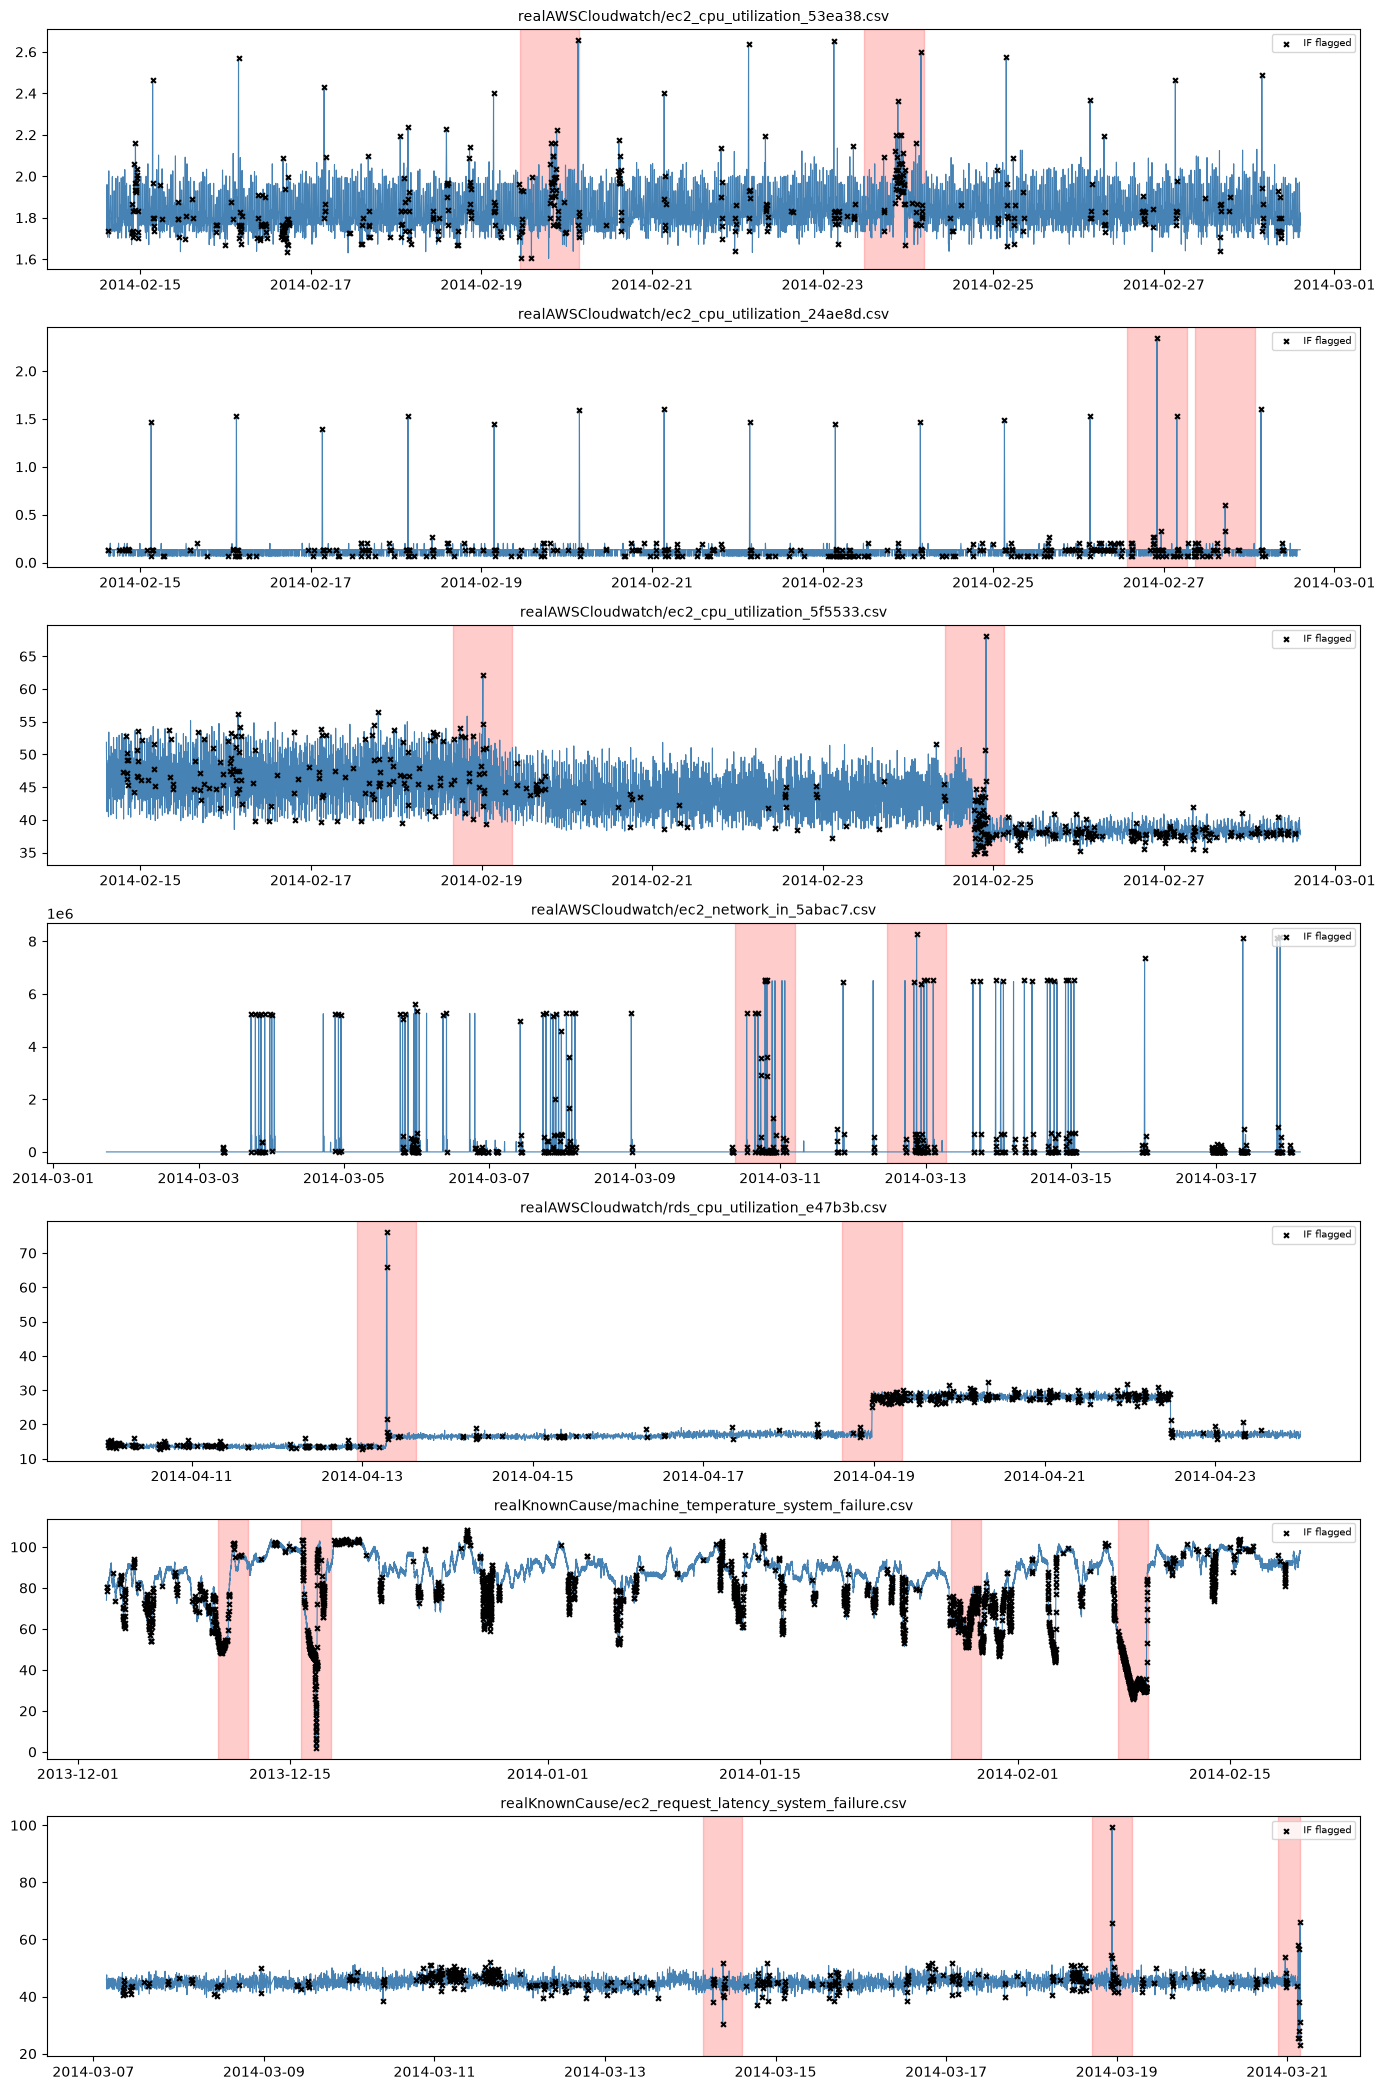

In [12]:
# Visual check: raw value with true anomaly windows (red shading) and Isolation Forest's
# flagged points (black x markers) overlaid, for all 7 files.

fig, axes = plt.subplots(len(FILES), 1, figsize=(14, 3 * len(FILES)))

for ax, key in zip(axes, FILES):
    df = load_file(key)
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()
    df['roll_std'] = df['value'].rolling(WINDOW).std()
    features = df[['roll_mean', 'roll_std']].dropna()
    model = IsolationForest(contamination=0.1, random_state=42)
    preds = model.fit_predict(features)
    df['if_flag'] = 0
    df.loc[features.index, 'if_flag'] = (preds == -1).astype(int)

    ax.plot(df['timestamp'], df['value'], linewidth=0.8, color='steelblue')
    for start, end in ANOMALY_WINDOWS.get(key, []):
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.2)
    flagged = df[df['if_flag'] == 1]
    ax.scatter(flagged['timestamp'], flagged['value'], color='black', marker='x', s=12, label='IF flagged', zorder=5)
    ax.set_title(key, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


### Day 5 summary

Combining rolling mean + rolling std with a simple OR-rule mostly raises recall (it catches anything either signal alone would catch) at some cost to precision, compared to whichever individual method had the best precision on that file. Isolation Forest, given the exact same two features, does noticeably better on several files — most dramatically on `machine_temperature_system_failure` (F1 ≈ 0.44 vs. 0.12–0.20 for every hand-tuned rule) — because it can learn a joint decision boundary between roll_mean and roll_std instead of checking each one against a fixed line independently. Full per-file discussion and the honest overall verdict are in Step C below.

In [13]:
# Step C support: F1 score per method per file, to objectively pick a "winner" per file
# instead of eyeballing precision/recall separately (F1 balances both into one number).

from sklearn.metrics import f1_score

f1_rows = []
for key in FILES:
    df = load_file(key)
    df['roll_mean'] = df['value'].rolling(WINDOW).mean()
    df['roll_std'] = df['value'].rolling(WINDOW).std()
    mean_threshold = df['value'].mean() + 1.0 * df['value'].std()
    std_threshold = df['roll_std'].mean() + 1.0 * df['roll_std'].std()

    mean_flag = (df['roll_mean'] > mean_threshold).astype(int)
    std_flag = (df['roll_std'] > std_threshold).astype(int)
    combined_flag = ((df['roll_mean'] > mean_threshold) | (df['roll_std'] > std_threshold)).astype(int)

    features = df[['roll_mean', 'roll_std']].dropna()
    model = IsolationForest(contamination=0.1, random_state=42)
    preds = model.fit_predict(features)
    if_flag = pd.Series(0, index=df.index)
    if_flag.loc[features.index] = (preds == -1).astype(int)

    row = {'file': key.split('/')[-1].replace('.csv', '')}
    for name, flag in [('mean', mean_flag), ('std', std_flag), ('combined', combined_flag), ('iforest', if_flag)]:
        row[name] = round(f1_score(df['is_anomaly'], flag, zero_division=0), 3)
    row['best_method'] = max(['mean', 'std', 'combined', 'iforest'], key=lambda m: row[m])
    f1_rows.append(row)

f1_df = pd.DataFrame(f1_rows)
f1_df


,file,mean,std,combined,iforest,best_method
0,ec2_cpu_utilization_53ea38,0.209,0.163,0.257,0.246,combined
1,ec2_cpu_utilization_24ae8d,0.068,0.072,0.072,0.161,iforest
2,ec2_cpu_utilization_5f5533,0.082,0.164,0.167,0.201,iforest
3,ec2_network_in_5abac7,0.227,0.228,0.228,0.213,std
4,rds_cpu_utilization_e47b3b,0.146,0.061,0.153,0.179,iforest
5,machine_temperature_system_failure,0.041,0.136,0.121,0.442,iforest
6,ec2_request_latency_system_failure,0.041,0.168,0.158,0.128,std


**Real F1 results (captured for reference):**

| file | mean | std | combined | iforest | best_method |
|---|---|---|---|---|---|
| ec2_cpu_utilization_53ea38 | 0.209 | 0.163 | 0.257 | 0.246 | combined |
| ec2_cpu_utilization_24ae8d | 0.068 | 0.072 | 0.072 | 0.161 | iforest |
| ec2_cpu_utilization_5f5533 | 0.082 | 0.164 | 0.167 | 0.201 | iforest |
| ec2_network_in_5abac7 | 0.227 | 0.228 | 0.228 | 0.213 | std (~3-way tie) |
| rds_cpu_utilization_e47b3b | 0.146 | 0.061 | 0.153 | 0.179 | iforest |
| machine_temperature_system_failure | 0.041 | 0.136 | 0.121 | 0.442 | iforest |
| ec2_request_latency_system_failure | 0.041 | 0.168 | 0.158 | 0.128 | std |

---
## Step C — Final Error Analysis

### Per-file analysis

**`ec2_cpu_utilization_53ea38`** — Best: **combined rule** (F1 0.257), Isolation Forest close behind (0.246), both clearly ahead of either single feature alone. Day 3/4 already hinted this file's anomaly is mostly a magnitude shift (rolling mean alone was the single best individual method here, precision 0.42). That holds up: both winners here rely partly on `roll_mean`, and the extra lift over mean-alone comes from also catching a few erratic-behavior anomalies the mean missed — i.e., it's *mostly* magnitude-based, with a smaller secondary erratic-behavior component. **Next step in production:** tune the threshold multiplier (fixed at 1.0×std for every file here) specifically for this metric family, or add a longer averaging window to cut short-blip false positives.

**`ec2_cpu_utilization_24ae8d`** — Best: **Isolation Forest** (F1 0.161), but every method is weak here (next-best 0.072). Day 2 already showed this file's normal/anomaly raw-value means are nearly identical (0.125 vs 0.134) — neither magnitude nor a single erraticness threshold finds this anomaly well. Only the 2D combination Isolation Forest builds finds it at all, and only modestly. **Next step:** this is the weakest file across every method tried in this project; more of the same two features won't fix it — worth trying a genuinely different feature (e.g. rate-of-change / first difference, or hour-of-day if there's a daily cycle in this server's load).

**`ec2_cpu_utilization_5f5533`** — Best: **Isolation Forest** (F1 0.201), close to combined (0.167) and std alone (0.164); mean alone much weaker (0.082). Day 4 already flagged this as a "std wins" file — an erratic-behavior anomaly, not a magnitude one. Isolation Forest confirms that story and improves on it slightly, likely by trimming some of the false positives a fixed std threshold alone produces. **Next step:** try computing `roll_std` at a second window size to catch jumpiness at more than one timescale.

**`ec2_network_in_5abac7`** — Essentially a **three-way tie** (mean 0.227, std 0.228, combined 0.228), Isolation Forest slightly behind (0.213). Day 2 already showed this file has a huge, obvious raw-value signal (anomaly mean ~3.3× normal) — the anomaly is a big magnitude spike that's easy to catch almost any way you slice it, so extra sophistication doesn't add much. **Next step:** for a file this "easy," the simplest method (plain rolling mean) is arguably the right production choice — no need for the compute/complexity overhead of a model when a threshold already works about as well.

**`rds_cpu_utilization_e47b3b`** — Best: **Isolation Forest** (F1 0.179); combined close (0.153); mean 0.146; std much worse (0.061 — very high precision, 0.54, but recall only 0.03). Day 4 found std had a real signal here but almost never fired. Isolation Forest's improvement over std-alone recall suggests the erratic-behavior signal is real, but Day 4's hand-picked std threshold was set too high specifically for this file. **Next step:** per-file (or per-metric-family) threshold tuning, rather than one global multiplier, would likely help this file most — the signal exists, the fixed cutoff just under-uses it.

**`machine_temperature_system_failure`** — Best: **Isolation Forest, decisively** (F1 0.442 vs. next-best std 0.136) — the single largest win for any method anywhere in this project. Day 2 showed this file's anomaly is a temperature **drop** (anomaly mean 64.0 vs. normal 88.4) — a large, real magnitude signal, but in the *opposite direction* from what our `roll_mean > threshold` rule was built to catch (it only looks for values going up). That design choice, not weak signal, is why rolling mean did so badly here (F1 0.041). Isolation Forest isn't direction-restricted the way our hand-built `>` threshold is, so it catches a drop just as easily as a spike — that alone explains most of the huge jump. **Next step:** this is the clearest case in the project of a hand-tuned rule's *own design* causing failure, not the underlying signal being weak. A two-sided threshold (`> upper` OR `< lower`) would likely close much of this gap without needing a model at all — worth testing as a cheap fix before reaching for more model complexity.

**`ec2_request_latency_system_failure`** — Best: **rolling std** (F1 0.168), combined close (0.158), Isolation Forest weaker (0.128), mean worst (0.041). Day 2's hint — anomaly std 4.66 vs. normal std 1.92, with means nearly identical — predicted exactly this: std-based methods should win here, and they do, with the simple hand-tuned std threshold beating even Isolation Forest. This is the one file where the simplest single-feature method beats the model outright. **Next step:** check whether Isolation Forest's underperformance here is a contamination mismatch — this file's true anomaly fraction (0.0858) is the one file noticeably below the ~0.10 used everywhere else; re-running with contamination matched to this file would be a useful diagnostic (though, as discussed above, using the true per-file rate at fit time is a "cheat" for a real production system, so any improvement from doing so would need to be framed as diagnostic evidence, not a legitimate deployment choice).

### Overall verdict

Across all 7 files, Isolation Forest had the best F1 score on 4 of them (`24ae8d`, `5f5533`, `rds_cpu_utilization_e47b3b`, `machine_temperature_system_failure`) — but the size of the win varies enormously. On `machine_temperature_system_failure` it's a dramatic, meaningful improvement (0.44 vs. 0.14 for the next-best method) because it fixes a *structural* blind spot in the hand-tuned rule (one-directional thresholding). On the other 3 files, Isolation Forest's F1 is a smaller improvement over the alternatives, and still weak in an absolute sense (0.16–0.20). On the remaining 3 files (`53ea38`, `ec2_network_in_5abac7`, `ec2_request_latency_system_failure`), a hand-tuned rule (the combined OR-rule or rolling std alone) matched or beat Isolation Forest outright.

**Honest conclusion:** Isolation Forest is *not* a universal upgrade over hand-tuned thresholds. It helps most exactly where the hand-tuned rule had a structural flaw (direction-blindness on the temperature file); it helps a little where the anomaly genuinely needs a 2D combination of magnitude and erraticness; and it adds nothing — or is slightly worse — where a single hand-picked feature already captured the anomaly well. This is a real, defensible finding, not a failure of the exercise: two features and 4,000–22,000 rows per file is a small, thin input for any model to add much beyond a good hand-tuned rule. The likely next lever for a real production system is **more/better features** (rate of change, time-of-day, multi-window statistics, a two-sided threshold) rather than a fancier model layered on the same two features — and, per-file, the fix that would help most is usually specific to that file's own anomaly shape, not a single global change.